# 04 - Content-Based Filtering
## Sistem Rekomendasi Produk Manufaktur

**Tujuan Notebook:**
- Implementasi Content-Based Filtering menggunakan TF-IDF
- Menghitung cosine similarity antar produk berdasarkan deskripsi
- Membuat fungsi rekomendasi berdasarkan kemiripan produk
- Evaluasi performa CBF dengan metrik Precision@K dan Recall@K

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load product information
products = pd.read_csv('../data/products_cleaned.csv')

# Load user-item matrix
user_item_matrix = pd.read_csv('../data/user_item_matrix.csv', index_col=0)

print(f"Products: {len(products):,}")
print(f"Users: {user_item_matrix.shape[0]:,}")
print(f"\nProduct data:")
products.head()

Products: 4,206
Users: 5,545

Product data:


,StockCode,Description,AvgPrice,TotalQuantitySold,UniqueCustomers
0,10002,inflatable political globe,0.840960,8479,164
1,10080,groovy cactus inflatable,0.509259,303,23
2,10120,doggy rubber,0.210000,648,52
3,10123C,hearts wrapping tape,0.621739,628,39
4,10123G,army camo wrapping tape,0.559231,2246,12


## 3. TF-IDF Vectorization

### 3.1 Prepare Text Data

In [3]:
print("=== Preparing Text Data ===")

# Check for missing descriptions
print(f"Missing descriptions: {products['Description'].isna().sum()}")

# Fill any missing descriptions with empty string
products['Description'] = products['Description'].fillna('')

print(f"\nSample descriptions:")
for i, desc in enumerate(products['Description'].head(10)):
    print(f"{i+1}. {desc}")

=== Preparing Text Data ===
Missing descriptions: 0

Sample descriptions:
1. inflatable political globe
2. groovy cactus inflatable
3. doggy rubber
4. hearts wrapping tape
5. army camo wrapping tape
6. spots on red bookcover tape
7. army camo bookcover tape
8. mini funky design tapes
9. colouring pencils brown tube
10. colouring pencils brown tube


### 3.2 Create TF-IDF Matrix

In [4]:
print("=== Creating TF-IDF Matrix ===")
print("This may take a few minutes...\n")

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=500,        # Limit to top 500 features
    stop_words='english',    # Remove common English words
    ngram_range=(1, 2),      # Use unigrams and bigrams
    min_df=2,                # Ignore terms that appear in less than 2 documents
    max_df=0.8               # Ignore terms that appear in more than 80% of documents
)

# Fit and transform
tfidf_matrix = tfidf.fit_transform(products['Description'])

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"Products: {tfidf_matrix.shape[0]:,}")
print(f"Features (terms): {tfidf_matrix.shape[1]:,}")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Show top features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features (terms):")
print(feature_names[:20])

=== Creating TF-IDF Matrix ===
This may take a few minutes...

TF-IDF Matrix shape: (4206, 500)
Products: 4,206
Features (terms): 500
Sparsity: 99.32%

Sample features (terms):
['10' '12' '20' '36' '3d' '50s' '50s christmas' '60' '72' 'acrylic'
 'album' 'alphabet' 'animal' 'ant' 'antique' 'apples' 'apron' 'art'
 'artificial' 'artificial flower']


## 4. Calculate Product Similarity Matrix

In [5]:
print("=== Calculating Product Similarity Matrix ===")
print("This may take a few minutes...\n")

# Calculate cosine similarity between all products
product_similarity = cosine_similarity(tfidf_matrix)

# Convert to DataFrame
product_similarity_df = pd.DataFrame(product_similarity,
                                     index=products['StockCode'],
                                     columns=products['StockCode'])

print(f"Product similarity matrix shape: {product_similarity_df.shape}")
print(f"\nSimilarity statistics (excluding diagonal):")
# Get upper triangle values (excluding diagonal)
upper_triangle = product_similarity[np.triu_indices_from(product_similarity, k=1)]
print(f"  Mean: {upper_triangle.mean():.4f}")
print(f"  Median: {np.median(upper_triangle):.4f}")
print(f"  Max: {upper_triangle.max():.4f}")
print(f"  Min: {upper_triangle.min():.4f}")

product_similarity_df.head()

=== Calculating Product Similarity Matrix ===
This may take a few minutes...

Product similarity matrix shape: (4206, 4206)

Similarity statistics (excluding diagonal):
  Mean: 0.0124
  Median: 0.0000
  Max: 1.0000
  Min: 0.0000


StockCode,10002,10080,10120,10123C,10123G,10124A,10124G,10125,10133,10134,...,90214T,90214V,90214Z,ADJUST,BANK CHARGES,C2,D,M,PADS,POST
StockCode,,,,,,,,,,,,,,,,,,,,,
10002,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10080,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10120,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10123C,0.0,0.0,0.0,1.000000,0.735467,0.468500,0.735467,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10123G,0.0,0.0,0.0,0.735467,1.000000,0.637011,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Content-Based Recommendation Function

In [6]:
def get_cbf_recommendations(user_id, user_item_matrix, product_similarity_df, top_n=10):
    """
    Generate product recommendations using Content-Based Filtering
    
    Parameters:
    - user_id: Target user ID
    - user_item_matrix: User-item interaction matrix
    - product_similarity_df: Product similarity matrix
    - top_n: Number of recommendations to return
    
    Returns:
    - DataFrame with recommended products and scores
    """
    
    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=['StockCode', 'CBF_Score'])
    
    # Get products purchased by user
    user_purchases = user_item_matrix.loc[user_id]
    purchased_products = user_purchases[user_purchases > 0]
    
    if len(purchased_products) == 0:
        return pd.DataFrame(columns=['StockCode', 'CBF_Score'])
    
    # Calculate weighted similarity scores
    product_scores = {}
    
    for product, quantity in purchased_products.items():
        if product not in product_similarity_df.index:
            continue
        
        # Get similar products
        similar_products = product_similarity_df.loc[product]
        
        # Add weighted scores (weight by quantity purchased)
        for similar_product, similarity in similar_products.items():
            # Don't recommend already purchased products
            if similar_product not in purchased_products.index:
                if similar_product not in product_scores:
                    product_scores[similar_product] = 0
                product_scores[similar_product] += similarity * quantity
    
    # Sort by score and get top N
    if not product_scores:
        return pd.DataFrame(columns=['StockCode', 'CBF_Score'])
    
    recommendations = pd.DataFrame(list(product_scores.items()),
                                   columns=['StockCode', 'CBF_Score'])
    recommendations = recommendations.sort_values('CBF_Score', ascending=False).head(top_n)
    recommendations = recommendations.reset_index(drop=True)
    
    return recommendations

print("CBF recommendation function defined!")

CBF recommendation function defined!


## 6. Test CBF Recommendations

In [7]:
# Test with a sample user
sample_user = user_item_matrix.index[0]

print(f"=== Testing CBF for Customer {sample_user} ===")

# Get user's purchase history
user_purchases = user_item_matrix.loc[sample_user]
purchased_products = user_purchases[user_purchases > 0]

print(f"\nCustomer has purchased {len(purchased_products)} products")
print(f"\nSample purchased products:")
for product in purchased_products.index[:5]:
    product_info = products[products['StockCode'] == product]
    if len(product_info) > 0:
        print(f"  - {product}: {product_info['Description'].values[0]}")

# Get recommendations
recommendations = get_cbf_recommendations(sample_user, user_item_matrix, 
                                          product_similarity_df, top_n=10)

print(f"\n=== Top 10 CBF Recommendations ===")
for idx, row in recommendations.iterrows():
    product_info = products[products['StockCode'] == row['StockCode']]
    if len(product_info) > 0:
        print(f"{idx+1:2d}. {row['StockCode']:10s} | Score: {row['CBF_Score']:8.4f} | {product_info['Description'].values[0]}")

=== Testing CBF for Customer 12346 ===

Customer has purchased 25 products

Sample purchased products:
  - 15056BL: edwardian parasol black
  - 15056N: edwardian parasol natural
  - 15056P: edwardian parasol pink
  - 20679: edwardian parasol red
  - 20682: red spotty childs umbrella

=== Top 10 CBF Recommendations ===
 1. 23167      | Score: 61260.6740 | small ceramic top storage jar
 2. 23165      | Score: 61142.8061 | large ceramic top storage jar
 3. 23020      | Score: 54987.9837 | glass  songbird storage jar
 4. 21664      | Score: 49966.6388 | ridged glass storage jar cream lid
 5. 23186      | Score: 46821.2215 | french style storage jar cafe
 6. 23187      | Score: 46821.2215 | french style storage jar bonbons
 7. 22073      | Score: 44599.2972 | retro spot storage jar
 8. 23185      | Score: 42264.6510 | french style storage jar jam
 9. 84429A     | Score: 31070.9931 | medium pink buddha head
10. 23017      | Score: 30651.2649 | apothecary measuring jar


## 7. Analyze Product Similarities

In [8]:
# Pick a sample product and show most similar products
sample_product = products['StockCode'].iloc[0]
sample_desc = products[products['StockCode'] == sample_product]['Description'].values[0]

print(f"=== Most Similar Products to: {sample_product} ===")
print(f"Description: {sample_desc}\n")

if sample_product in product_similarity_df.index:
    similar_products = product_similarity_df.loc[sample_product].sort_values(ascending=False)[1:11]
    
    print("Top 10 most similar products:")
    for i, (product, similarity) in enumerate(similar_products.items(), 1):
        product_info = products[products['StockCode'] == product]
        if len(product_info) > 0:
            print(f"{i:2d}. {product:10s} | Similarity: {similarity:.4f} | {product_info['Description'].values[0]}")
else:
    print("Product not found in similarity matrix")

=== Most Similar Products to: 10002 ===
Description: inflatable political globe

Top 10 most similar products:
 1. 37482P     | Similarity: 0.0000 | cubic mug pink polka dot
 2. 37485      | Similarity: 0.0000 | english rose tea set in gift box
 3. 37489A     | Similarity: 0.0000 | yellowpink flower design big mug
 4. 37489B     | Similarity: 0.0000 | blueyellow flower design big mug
 5. 37489C     | Similarity: 0.0000 | greenblue flower design big mug
 6. 37489D     | Similarity: 0.0000 | pinkgreen flower design big mug
 7. 37491A     | Similarity: 0.0000 | yellowpink ceramic candle holder
 8. 37491B     | Similarity: 0.0000 | blueyellow ceramic candle holder
 9. 37491C     | Similarity: 0.0000 | greenblue ceramic candle holder
10. 37491D     | Similarity: 0.0000 | purpleblue ceramic candle holder


## 8. Evaluation

### 8.1 Load Train-Test Split

In [9]:
# Recreate train-test split (same as CF notebook)
print("=== Creating Train-Test Split ===")

train_matrix = user_item_matrix.copy()
test_matrix = pd.DataFrame(0, index=user_item_matrix.index, columns=user_item_matrix.columns)

np.random.seed(42)
test_ratio = 0.2

for user_id in user_item_matrix.index:
    purchased_products = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist()
    
    if len(purchased_products) > 1:
        n_test = max(1, int(len(purchased_products) * test_ratio))
        test_products = np.random.choice(purchased_products, size=n_test, replace=False)
        
        for product in test_products:
            test_matrix.loc[user_id, product] = user_item_matrix.loc[user_id, product]
            train_matrix.loc[user_id, product] = 0

print(f"Train set non-zero interactions: {(train_matrix > 0).sum().sum():,}")
print(f"Test set non-zero interactions: {(test_matrix > 0).sum().sum():,}")

=== Creating Train-Test Split ===
Train set non-zero interactions: 386,372
Test set non-zero interactions: 93,849


### 8.2 Evaluation Functions

In [10]:
def precision_at_k(recommended, relevant, k):
    recommended_at_k = recommended[:k]
    relevant_and_recommended = set(recommended_at_k).intersection(set(relevant))
    return len(relevant_and_recommended) / k if k > 0 else 0

def recall_at_k(recommended, relevant, k):
    recommended_at_k = recommended[:k]
    relevant_and_recommended = set(recommended_at_k).intersection(set(relevant))
    return len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

def f1_score_at_k(precision, recall):
    if precision + recall == 0:
        return 0
    return 2 * (precision * recall) / (precision + recall)

print("Evaluation functions defined!")

Evaluation functions defined!


### 8.3 Evaluate CBF on Test Set

In [11]:
print("=== Evaluating Content-Based Filtering ===")
print("This may take several minutes...\n")

K_VALUES = [5, 10, 20]
results = {k: {'precision': [], 'recall': [], 'f1': []} for k in K_VALUES}

# Sample users for evaluation
sample_size = min(500, len(user_item_matrix))
eval_users = np.random.choice(user_item_matrix.index, size=sample_size, replace=False)

for i, user_id in enumerate(eval_users):
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{len(eval_users)} users...")
    
    # Get relevant items (items in test set)
    relevant_items = test_matrix.loc[user_id][test_matrix.loc[user_id] > 0].index.tolist()
    
    if len(relevant_items) == 0:
        continue
    
    # Get recommendations
    recommendations = get_cbf_recommendations(user_id, train_matrix, 
                                              product_similarity_df, top_n=max(K_VALUES))
    
    if len(recommendations) == 0:
        continue
    
    recommended_items = recommendations['StockCode'].tolist()
    
    # Calculate metrics for different K values
    for k in K_VALUES:
        precision = precision_at_k(recommended_items, relevant_items, k)
        recall = recall_at_k(recommended_items, relevant_items, k)
        f1 = f1_score_at_k(precision, recall)
        
        results[k]['precision'].append(precision)
        results[k]['recall'].append(recall)
        results[k]['f1'].append(f1)

print(f"\nEvaluation complete!")
print(f"Evaluated on {len(eval_users)} users\n")

# Print results
print("=" * 60)
print("CONTENT-BASED FILTERING EVALUATION RESULTS")
print("=" * 60)

for k in K_VALUES:
    avg_precision = np.mean(results[k]['precision'])
    avg_recall = np.mean(results[k]['recall'])
    avg_f1 = np.mean(results[k]['f1'])
    
    print(f"\nMetrics @{k}:")
    print(f"  Precision@{k}: {avg_precision:.4f}")
    print(f"  Recall@{k}:    {avg_recall:.4f}")
    print(f"  F1-Score@{k}:  {avg_f1:.4f}")

print("\n" + "=" * 60)

=== Evaluating Content-Based Filtering ===
This may take several minutes...

Processed 100/500 users...
Processed 200/500 users...
Processed 300/500 users...
Processed 400/500 users...
Processed 500/500 users...

Evaluation complete!
Evaluated on 500 users

CONTENT-BASED FILTERING EVALUATION RESULTS

Metrics @5:
  Precision@5: 0.0680
  Recall@5:    0.0402
  F1-Score@5:  0.0366

Metrics @10:
  Precision@10: 0.0540
  Recall@10:    0.0617
  F1-Score@10:  0.0410

Metrics @20:
  Precision@20: 0.0455
  Recall@20:    0.0930
  F1-Score@20:  0.0448



### 8.4 Visualize Evaluation Results

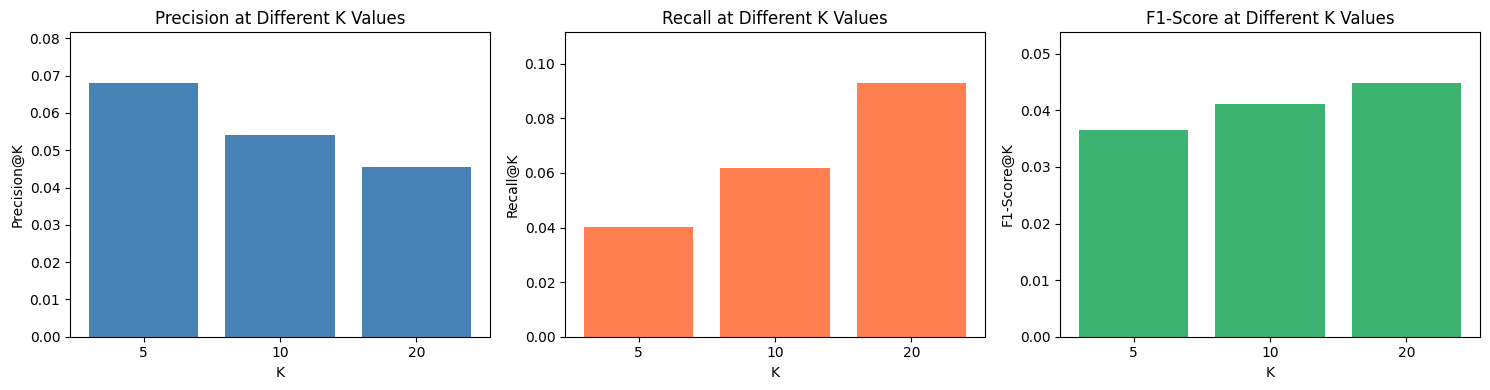

In [12]:
# Prepare data for visualization
metrics_data = []
for k in K_VALUES:
    metrics_data.append({
        'K': k,
        'Precision': np.mean(results[k]['precision']),
        'Recall': np.mean(results[k]['recall']),
        'F1-Score': np.mean(results[k]['f1'])
    })

metrics_df = pd.DataFrame(metrics_data)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Precision
axes[0].bar(metrics_df['K'].astype(str), metrics_df['Precision'], color='steelblue')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].set_title('Precision at Different K Values')
axes[0].set_ylim([0, max(metrics_df['Precision']) * 1.2])

# Recall
axes[1].bar(metrics_df['K'].astype(str), metrics_df['Recall'], color='coral')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Recall@K')
axes[1].set_title('Recall at Different K Values')
axes[1].set_ylim([0, max(metrics_df['Recall']) * 1.2])

# F1-Score
axes[2].bar(metrics_df['K'].astype(str), metrics_df['F1-Score'], color='mediumseagreen')
axes[2].set_xlabel('K')
axes[2].set_ylabel('F1-Score@K')
axes[2].set_title('F1-Score at Different K Values')
axes[2].set_ylim([0, max(metrics_df['F1-Score']) * 1.2])

plt.tight_layout()
plt.show()

## 9. Save CBF Model Components

In [13]:
print("=== Saving CBF Model Components ===")

# Save TF-IDF vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ Saved: tfidf_vectorizer.pkl")

# Save TF-IDF matrix
with open('../models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print("✓ Saved: tfidf_matrix.pkl")

# Save product similarity matrix
product_similarity_df.to_csv('../models/product_similarity_matrix.csv')
print("✓ Saved: product_similarity_matrix.csv")

# Save evaluation results
with open('../models/cbf_evaluation_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✓ Saved: cbf_evaluation_results.pkl")

# Save metrics summary
metrics_df.to_csv('../models/cbf_metrics_summary.csv', index=False)
print("✓ Saved: cbf_metrics_summary.csv")

print("\nAll CBF components saved successfully!")

=== Saving CBF Model Components ===
✓ Saved: tfidf_vectorizer.pkl
✓ Saved: tfidf_matrix.pkl
✓ Saved: product_similarity_matrix.csv
✓ Saved: cbf_evaluation_results.pkl
✓ Saved: cbf_metrics_summary.csv

All CBF components saved successfully!


## 10. Summary

In [14]:
print("\n" + "="*70)
print("CONTENT-BASED FILTERING SUMMARY")
print("="*70)

print(f"\n1. MODEL CONFIGURATION")
print(f"   Algorithm: Content-Based Filtering with TF-IDF")
print(f"   Similarity metric: Cosine Similarity")
print(f"   Max features: 500")
print(f"   N-gram range: (1, 2)")

print(f"\n2. DATA STATISTICS")
print(f"   Total products: {len(products):,}")
print(f"   TF-IDF features: {tfidf_matrix.shape[1]:,}")
print(f"   TF-IDF sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

print(f"\n3. PERFORMANCE METRICS")
for k in K_VALUES:
    print(f"   @{k}: Precision={np.mean(results[k]['precision']):.4f}, "
          f"Recall={np.mean(results[k]['recall']):.4f}, "
          f"F1={np.mean(results[k]['f1']):.4f}")

print(f"\n4. STRENGTHS")
print(f"   ✓ No cold start problem for new users")
print(f"   ✓ Recommendations are explainable")
print(f"   ✓ Works well with rich product descriptions")

print(f"\n5. LIMITATIONS")
print(f"   ✗ Limited diversity (only similar items)")
print(f"   ✗ Requires good product descriptions")
print(f"   ✗ Cannot discover unexpected preferences")

print("\n" + "="*70)


CONTENT-BASED FILTERING SUMMARY

1. MODEL CONFIGURATION
   Algorithm: Content-Based Filtering with TF-IDF
   Similarity metric: Cosine Similarity
   Max features: 500
   N-gram range: (1, 2)

2. DATA STATISTICS
   Total products: 4,206
   TF-IDF features: 500
   TF-IDF sparsity: 99.32%

3. PERFORMANCE METRICS
   @5: Precision=0.0680, Recall=0.0402, F1=0.0366
   @10: Precision=0.0540, Recall=0.0617, F1=0.0410
   @20: Precision=0.0455, Recall=0.0930, F1=0.0448

4. STRENGTHS
   ✓ No cold start problem for new users
   ✓ Recommendations are explainable
   ✓ Works well with rich product descriptions

5. LIMITATIONS
   ✗ Limited diversity (only similar items)
   ✗ Requires good product descriptions
   ✗ Cannot discover unexpected preferences



---
**End of Content-Based Filtering Notebook**

**Next Steps:**
- `05_svd_matrix_factorization.ipynb` - Train SVD model
- `06_hybrid_evaluation.ipynb` - Combine CF + CBF + SVD